In [ ]:
!pip install --upgrade numpy
!pip install --upgrade gensim

# Restart the runtime here (optional but recommended)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 747.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 24.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.5 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.5 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━

In [ ]:
import gensim.downloader as api

# Load GloVe Twitter 200D model (~1.2GB, loads from cache after first time)
glove_model = api.load("glove-twitter-200")

[==================================================] 100.0% 758.5/758.5MB downloaded


Problem Statement

Twitter is a microblogging and social networking service on which users post and interact with messages known as "tweets". Every second, on average, around 6,000 tweets are tweeted on Twitter, corresponding to over 350,000 tweets sent per minute, 500 million tweets per day.

Twitter wants to automatically tag and analyze tweets for better understanding of the trends and topics without being dependent on the hashtags that the users use. Many users do not use hashtags or sometimes use wrong or mis-spelled tags, so they want to completely remove this problem and create a system of recognizing important content of the tweets.

Named Entity Recognition (NER) is an important subtask of information extraction that seeks to locate and recognise named entities.

You need to train models that will be able to identify the various named entities.

Downloading Dataset:
Import the test, train data and understand the structure of the data.

usual exploratory analysis steps like checking the structure & characteristics of the dataset

In [ ]:
import gdown
folder_url = "https://drive.google.com/drive/folders/14IgdWzzpjp166rhNhp9UFenjUp_czaGo"
gdown.download_folder(folder_url, quiet=False, use_cookies=False)

Retrieving folder contents


Processing file 14_VHffl1qBUEnZ1IWFHnh6B9M5_A-Wf8 wnut 16.txt.conll
Processing file 1cnrGjppPOU_NtHNpGu0RJGg1CUNNsse_ wnut 16test.txt.conll


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=14_VHffl1qBUEnZ1IWFHnh6B9M5_A-Wf8
To: /content/Datasets/wnut 16.txt.conll
100%|██████████| 403k/403k [00:00<00:00, 73.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1cnrGjppPOU_NtHNpGu0RJGg1CUNNsse_
To: /content/Datasets/wnut 16test.txt.conll
100%|██████████| 635k/635k [00:00<00:00, 102MB/s]
Download completed


['/content/Datasets/wnut 16.txt.conll',
 '/content/Datasets/wnut 16test.txt.conll']

Data Description

Dataset is annotated with 10 fine-grained NER categories: person, geo-location, company, facility, product,music artist, movie, sports team, tv show and other. Dataset was extracted from tweets and is structured in CoNLL format., in English language. Containing in Text file format.

The CoNLL format is a text file with one word per line with sentences separated by an empty line. The first word in a line should be the word and the last word should be the label.

Consider the two sentences below;

Harry Potter was a student living in london

Albus Dumbledore went to the Disney World

These two sentences can be prepared in a CoNLL formatted text file as follows.

Harry B-PER

Potter I-PER

was O

a O

student O

Living O

in O

London B-geo-loc

Albus B-PER

Dumbledore I-PER

went O

to O

the O

Disney B-facility

World I-facility

In [ ]:
import re
def read_data(file_path):
  tokens=[]
  tags=[]
  tweet_tokens=[]
  tweet_tags=[]
  for line in open(file_path,encoding='utf-8'):
    line=line.strip()
    if not line:
      if tweet_tokens:
        tokens.append(tweet_tokens)
        tags.append(tweet_tags)

      tweet_tokens=[]
      tweet_tags=[]
    else:
      token,tag=line.split()
      token=re.sub('http[s]*://.*','<URL>',token.lower())
      token=re.sub('@.*','<USR>',token)
      tweet_tokens.append(token)
      tweet_tags.append(tag)
  return tokens,tags

In [ ]:
train_tokens, train_tags = read_data('/content/Datasets/wnut 16.txt.conll')
train_tokens[0:2]

[['<USR>',
  '<USR>',
  'they',
  'will',
  'be',
  'all',
  'done',
  'by',
  'sunday',
  'trust',
  'me',
  '*wink*'],
 ['made',
  'it',
  'back',
  'home',
  'to',
  'ga',
  '.',
  'it',
  'sucks',
  'not',
  'to',
  'be',
  'at',
  'disney',
  'world',
  ',',
  'but',
  'its',
  'good',
  'to',
  'be',
  'home',
  '.',
  'time',
  'to',
  'start',
  'planning',
  'the',
  'next',
  'disney',
  'world',
  'trip',
  '.']]

In [ ]:
test_tokens, test_tags = read_data('/content/Datasets/wnut 16test.txt.conll')

In [ ]:
import pandas as pd
train_df=pd.DataFrame({'tokens':train_tokens,'tags':train_tags})
test_df=pd.DataFrame({'tokens':test_tokens,'tags':test_tags})
train_df.head()

,tokens,tags
0,"[<USR>, <USR>, they, will, be, all, done, by, ...","[O, O, O, O, O, O, O, O, O, O, O, O]"
1,"[made, it, back, home, to, ga, ., it, sucks, n...","[O, O, O, O, O, B-geo-loc, O, O, O, O, O, O, O..."
2,"[', breaking, dawn, ', returns, to, vancouver,...","[O, B-movie, I-movie, O, O, O, B-geo-loc, O, O..."
3,"[<USR>, perhaps, ,, but, folks, may, find, som...","[O, O, O, O, O, O, O, O, O, O, O, O, O, O, O, ..."
4,"[<USR>, aye, been, tonight, -, excellent]","[O, O, O, O, O, O]"


In [ ]:
train_df.shape,test_df.shape

((2393, 2), (3849, 2))

Train Max length: 39
Test Max length: 35


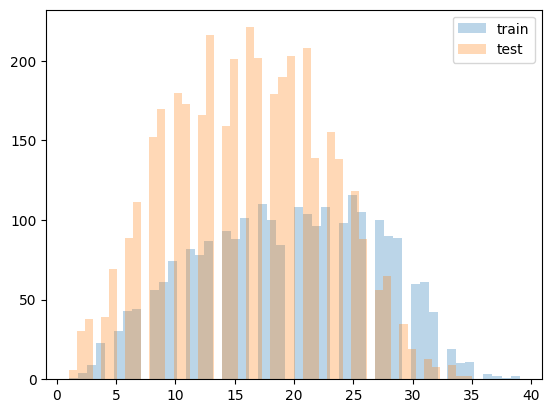

In [ ]:
import matplotlib.pyplot as plt
# Length of sequences
train_seq_len = [len(item) for item in train_df['tokens']]
test_seq_len = [len(item) for item in test_df['tokens']]
print(f'Train Max length: {max(train_seq_len)}')
print(f'Test Max length: {max(test_seq_len)}')
plt.hist(train_seq_len, bins=50, alpha=0.3, label='train')
plt.hist(test_seq_len, bins=50, alpha=0.3, label='test')
plt.legend();

Data preprocessing

Preparing the data in the format required by models

In [ ]:
from collections import defaultdict

# tokens, tags are lists of token and tag sequences (list of list of strings)

word2idx = {'PAD': 0, 'UNK': 1}
tag2idx = {'PAD': 0}
idx = 2

for sent in train_tokens:
    for word in sent:
        if word not in word2idx:
            word2idx[word] = idx
            idx += 1

idx = 1
for tag_seq in train_tags:
    for tag in tag_seq:
        if tag not in tag2idx:
            tag2idx[tag] = idx
            idx += 1

idx2tag = {v: k for k, v in tag2idx.items()}


In [ ]:
word2idx

{'PAD': 0,
 'UNK': 1,
 '<USR>': 2,
 'they': 3,
 'will': 4,
 'be': 5,
 'all': 6,
 'done': 7,
 'by': 8,
 'sunday': 9,
 'trust': 10,
 'me': 11,
 '*wink*': 12,
 'made': 13,
 'it': 14,
 'back': 15,
 'home': 16,
 'to': 17,
 'ga': 18,
 '.': 19,
 'sucks': 20,
 'not': 21,
 'at': 22,
 'disney': 23,
 'world': 24,
 ',': 25,
 'but': 26,
 'its': 27,
 'good': 28,
 'time': 29,
 'start': 30,
 'planning': 31,
 'the': 32,
 'next': 33,
 'trip': 34,
 "'": 35,
 'breaking': 36,
 'dawn': 37,
 'returns': 38,
 'vancouver': 39,
 'on': 40,
 'january': 41,
 '11th': 42,
 '<URL>': 43,
 'perhaps': 44,
 'folks': 45,
 'may': 46,
 'find': 47,
 'something': 48,
 'in': 49,
 'gallery': 50,
 'that': 51,
 'is': 52,
 'helpful': 53,
 'their': 54,
 'day-to-day': 55,
 'work': 56,
 'as': 57,
 'well': 58,
 'even': 59,
 'just': 60,
 'use': 61,
 'aye': 62,
 'been': 63,
 'tonight': 64,
 '-': 65,
 'excellent': 66,
 'rt': 67,
 ':': 68,
 'this': 69,
 'if': 70,
 'you': 71,
 'want': 72,
 'go': 73,
 'live': 74,
 'ustream': 75,
 'later': 76

In [ ]:
tag2idx

{'PAD': 0,
 'O': 1,
 'B-geo-loc': 2,
 'B-facility': 3,
 'I-facility': 4,
 'B-movie': 5,
 'I-movie': 6,
 'B-company': 7,
 'B-product': 8,
 'B-person': 9,
 'B-other': 10,
 'I-other': 11,
 'B-sportsteam': 12,
 'I-sportsteam': 13,
 'I-product': 14,
 'I-company': 15,
 'I-person': 16,
 'I-geo-loc': 17,
 'B-tvshow': 18,
 'B-musicartist': 19,
 'I-musicartist': 20,
 'I-tvshow': 21}

Use a word2vec model to initialize embeddings. Using Glove model for embedding to give better vectors for the tweet data

In [ ]:
import numpy as np

embedding_dim = 200
embedding_matrix = np.zeros((len(word2idx), embedding_dim))

for word, i in word2idx.items():
    if word in glove_model:
        embedding_matrix[i] = glove_model[word]
    else:
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embedding_dim,))

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 50  # or based on your dataset

X = [[word2idx.get(w, word2idx['UNK']) for w in s] for s in train_tokens]
X = pad_sequences(X, maxlen=MAX_LEN, padding='post', value=word2idx['PAD'])

y = [[tag2idx[t] for t in ts] for ts in train_tags]
y = pad_sequences(y, maxlen=MAX_LEN, padding='post', value=tag2idx['PAD'])

In [ ]:
X

array([[  2,   2,   3, ...,   0,   0,   0],
       [ 13,  14,  15, ...,   0,   0,   0],
       [ 35,  36,  37, ...,   0,   0,   0],
       ...,
       [190,  84, 577, ...,   0,   0,   0],
       [ 67,   2,  68, ...,   0,   0,   0],
       [  2, 157,  71, ...,   0,   0,   0]], dtype=int32)

BI-LSTM model

Could not use CRF , as the packages have version conflicts on python 3.11 env.

In [ ]:
from keras.models import Model
from tensorflow.keras.layers import Input

# LSTM components
from keras.layers import LSTM, Embedding, Dense, TimeDistributed, Dropout, Bidirectional





In [ ]:
from tensorflow_addons.utils.types import FloatTensorLike, TensorLike
# CRF layer
from tensorflow_addons.layers import CRF
# Sigmoid focal cross entropy loss. works well with highly unbalanced input data
from tensorflow_addons.losses import SigmoidFocalCrossEntropy
from tensorflow_addons.optimizers import AdamW

In [ ]:
X[1]

array([13, 14, 15, 16, 17, 18, 19, 14, 20, 21, 17,  5, 22, 23, 24, 25, 26,
       27, 28, 17,  5, 16, 19, 29, 17, 30, 31, 32, 33, 23, 24, 34, 19,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
      dtype=int32)

Tensorflow model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, TimeDistributed, Dense

input = Input(shape=(MAX_LEN,))
model = Embedding(input_dim=len(word2idx),
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
                  input_length=MAX_LEN,
                  mask_zero=True,
                  trainable=False)(input)

model = Bidirectional(LSTM(units=64, return_sequences=True))(model)
model = TimeDistributed(Dense(len(tag2idx), activation='softmax'))(model)

model = Model(inputs=input, outputs=model)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 200)   │  1,504,400 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 50)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 50, 128)   │    135,680 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 50, 22)    │      2,838 │ bidirectional[0]… │
│ (TimeDistributed)   │                   │            │ not_equal[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,642,918 (6.27 MB)

 Trainable params: 138,518 (541.09 KB)

 Non-trainable params: 1,504,400 (5.74 MB)

In [ ]:
from tensorflow.keras.utils import to_categorical

# y: shape (num_samples, max_len) — each element is a tag index
y = to_categorical(y, num_classes=len(tag2idx))  # shape: (num_samples, max_len, num_classes)


In [ ]:
y

array([[[0., 1., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 1., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       [[0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 1., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        [0., 1., 0., ..., 0., 0., 0.],
        ...,
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0.

train test split for BI-LSTM model.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, TimeDistributed, Dense

input = Input(shape=(MAX_LEN,))
model = Embedding(input_dim=len(word2idx),
                  output_dim=embedding_dim,
                  weights=[embedding_matrix],
                  input_length=MAX_LEN,
                  # mask_zero=True,  # Remove or handle masking manually
                  trainable=False)(input)

model = Bidirectional(LSTM(units=64, return_sequences=True))(model)
model = TimeDistributed(Dense(len(tag2idx), activation='softmax'))(model)

model = Model(inputs=input, outputs=model)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])  # Changed loss function
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 50, 200)        │     1,504,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 50, 128)        │       135,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 50, 22)         │         2,838 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,642,918 (6.27 MB)

 Trainable params: 138,518 (541.09 KB)

 Non-trainable params: 1,504,400 (5.74 MB)

Train the model

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=32,
    epochs=10,
    verbose=1
)


Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 120ms/step - accuracy: 0.8566 - loss: 0.9171 - val_accuracy: 0.9801 - val_loss: 0.1335
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step - accuracy: 0.9796 - loss: 0.1333 - val_accuracy: 0.9801 - val_loss: 0.1176
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.9796 - loss: 0.1178 - val_accuracy: 0.9801 - val_loss: 0.1073
Epoch 4/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.9808 - loss: 0.1029 - val_accuracy: 0.9802 - val_loss: 0.0997
Epoch 5/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 85ms/step - accuracy: 0.9780 - loss: 0.1074 - val_accuracy: 0.9808 - val_loss: 0.0926
Epoch 6/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 98ms/step - accuracy: 0.9803 - loss: 0.0932 - val_accuracy: 0.9814 - val_loss: 0.0873
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 93ms/step - accuracy: 0.9812 - loss: 0.0874 - val_accuracy: 0.9818 - val_loss: 0.0828
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.9808 - loss: 0.0857 - val_accuracy: 0.9

Evaluation of BI-LSTM model

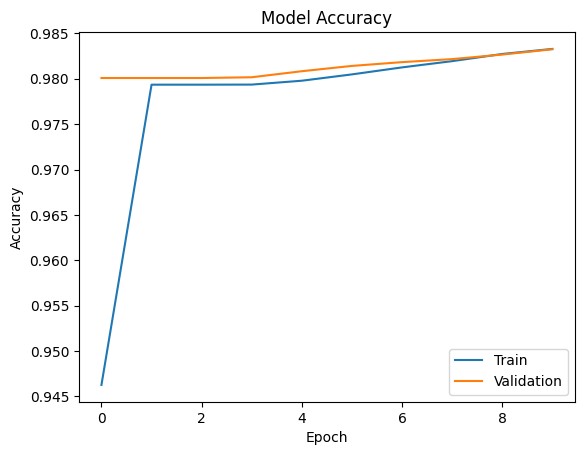

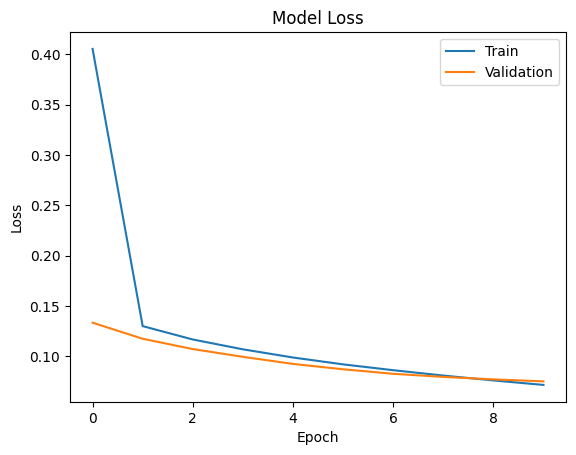

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()


In [ ]:
loss, accuracy = model.evaluate(X_val, y_val)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9853 - loss: 0.0671
Validation Loss: 0.0753
Validation Accuracy: 0.9833


In [ ]:
from sklearn.metrics import classification_report
import numpy as np
from itertools import chain

# Get predictions
y_pred = model.predict(X_val)
y_pred = np.argmax(y_pred, axis=-1)
y_true = np.argmax(y_val, axis=-1)

# Map indices to tags
y_pred_tags = [[idx2tag[i] for i in row] for row in y_pred]
y_true_tags = [[idx2tag[i] for i in row] for row in y_true]

# Flatten the sequences for report
y_pred_flat = list(chain.from_iterable(y_pred_tags))
y_true_flat = list(chain.from_iterable(y_true_tags))

print(classification_report(y_true_flat, y_pred_flat))


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step
              precision    recall  f1-score   support

   B-company       1.00      0.18      0.31        22
  B-facility       0.00      0.00      0.00         7
   B-geo-loc       0.55      0.37      0.44        30
     B-movie       0.00      0.00      0.00         3
     B-other       0.00      0.00      0.00        23
    B-person       0.60      0.69      0.64        42
   B-product       0.00      0.00      0.00        13
B-sportsteam       0.00      0.00      0.00         2
    B-tvshow       0.00      0.00      0.00         4
   I-company       0.00      0.00      0.00         4
  I-facility       0.00      0.00      0.00         7
   I-geo-loc       0.00      0.00      0.00         7
     I-movie       0.00      0.00      0.00         5
     I-other       0.00      0.00      0.00        31
    I-person       0.75      0.39      0.51        23
   I-product       0.00      0.00      0.00        12
I-sportsteam       0.00      0.00      0.0

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Hyper parameter tuning for BI-LSTM

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, RMSprop, SGD


In [ ]:
def build_model(optimizer='adam', lstm_units=64):
    input = tf.keras.layers.Input(shape=(MAX_LEN,))


    model_1 = tf.keras.layers.Embedding(
        input_dim=len(word2idx),
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        mask_zero=True,
        trainable=False)(input)

    model_1 = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(units=lstm_units, return_sequences=True))(model)

    model_1 = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(64, activation='relu'))(model)

    output_1 = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(len(tag2idx), activation='softmax'))(model)

    model_1 = tf.keras.models.Model(inputs=input, outputs=output)
    model_1.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model_1


In [ ]:
def build_model(optimizer='adam', lstm_units=64):
    input_layer = tf.keras.layers.Input(shape=(MAX_LEN,))

    x = tf.keras.layers.Embedding(
        input_dim=len(word2idx),
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        mask_zero=False,
        trainable=False
    )(input_layer)

    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(units=lstm_units, return_sequences=True)
    )(x)

    x = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(64, activation='relu')
    )(x)

    output_layer = tf.keras.layers.TimeDistributed(
        tf.keras.layers.Dense(len(tag2idx), activation='softmax')
    )(x)

    model = tf.keras.models.Model(inputs=input_layer, outputs=output_layer)

    # Handle optimizer type (string or object)
    if isinstance(optimizer, str):
        optimizer = tf.keras.optimizers.get(optimizer)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

    return model


In [ ]:
def train_model(optimizer='adam', lstm_units=64, epochs=10, batch_size=32):
    model = build_model(optimizer=optimizer, lstm_units=lstm_units)

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=2, verbose=1, restore_best_weights=True),
        ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min')
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    return model, history


In [ ]:
# Try different optimizers and units
optimizers = ['adam', 'rmsprop', 'sgd']
units = [64, 128]
epoch_choices = [5, 10]

results = {}

for opt in optimizers:
    for u in units:
        for e in epoch_choices:
            print(f"Training with optimizer={opt}, LSTM units={u}, epochs={e}")
            model, history = train_model(optimizer=opt, lstm_units=u, epochs=e)
            val_acc = max(history.history['val_accuracy'])
            key = f"{opt}_units{u}_epochs{e}"
            results[key] = val_acc


Training with optimizer=adam, LSTM units=64, epochs=5
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.8436 - loss: 0.8671

68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 139ms/step - accuracy: 0.8465 - loss: 0.8531 - val_accuracy: 0.9801 - val_loss: 0.1311
Epoch 2/5
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9803 - loss: 0.1247

68/68 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.9803 - loss: 0.1247 - val_accuracy: 0.9801 - val_loss: 0.1139
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9790 - loss: 0.1153

...

68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - accuracy: 0.9787 - loss: 0.1583 - val_accuracy: 0.9795 - val_loss: 0.1497
Epoch 7/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9784 - loss: 0.1591

68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 186ms/step - accuracy: 0.9784 - loss: 0.1590 - val_accuracy: 0.9798 - val_loss: 0.1473
Epoch 8/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9797 - loss: 0.1486

68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 186ms/step - accuracy: 0.9797 - loss: 0.1486 - val_accuracy: 0.9799 - val_loss: 0.1453
Epoch 9/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.9799 - loss: 0.1462

68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 185ms/step - accuracy: 0.9799 - loss: 0.1462 - val_accuracy: 0.9799 - val_loss: 0.1434
Epoch 10/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9805 - loss: 0.1418

68/68 ━━━━━━━━━━━━━━━━━━━━ 20s 184ms/step - accuracy: 0.9804 - loss: 0.1419 - val_accuracy: 0.9799 - val_loss: 0.1418
Restoring model weights from the end of the best epoch: 10.


In [ ]:
# Load best model (saved via checkpoint)
from tensorflow.keras.models import load_model
best_model = load_model('best_model.h5')

loss, accuracy = best_model.evaluate(X_val, y_val)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.9825 - loss: 0.1298
Validation Loss: 0.1418
Validation Accuracy: 0.9799


In [ ]:
import seaborn as sns

Loading the Transformer model

You can use the 'bert-base-uncased' model from the transformers library

Load the model and the model config

In [ ]:
!pip install transformers datasets seqeval -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.3 MB/s eta 0:00:00


In [ ]:
from transformers import BertTokenizerFast, TFBertForTokenClassification, DataCollatorForTokenClassification
from sklearn.model_selection import train_test_split
from transformers import create_optimizer, Trainer, TrainingArguments
import tensorflow as tf
import numpy as np
import evaluate
import os


In [ ]:
unique_tags = sorted(set(tag for seq in train_tags for tag in seq))

In [ ]:
tag2id = {tag: idx for idx, tag in enumerate(unique_tags)}
id2tag = {idx: tag for tag, idx in tag2id.items()}

Get the tokenizer for 'bert-base-uncased' model

In [ ]:
from transformers import BertTokenizerFast, BertForTokenClassification

model_name = "bert-base-uncased"
tokenizer = BertTokenizerFast.from_pretrained(model_name)
model = BertForTokenClassification.from_pretrained(model_name, num_labels=len(unique_tags))


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
unique_labels = list(set(label for doc in train_tags for label in doc))
label2id = {label: idx for idx, label in enumerate(sorted(unique_labels))}
id2label = {v: k for k, v in label2id.items()}


In [ ]:
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')






Train test split the data

In [ ]:
def tokenize_and_align(example):
    tokens = example['tokens']
    labels = example['ner_tags']

    tokenized = tokenizer(tokens, is_split_into_words=True, truncation=True, padding='max_length', max_length=64)
    word_ids = tokenized.word_ids()

    aligned_labels = []
    prev_word_idx = None
    for word_idx in word_ids:
        if word_idx is None:
            aligned_labels.append(-100)
        elif word_idx != prev_word_idx:
            aligned_labels.append(label2id[labels[word_idx]])
        else:
            aligned_labels.append(-100)
        prev_word_idx = word_idx

    tokenized['labels'] = aligned_labels
    return tokenized


In [ ]:
import torch
from transformers import BertTokenizerFast, BertForTokenClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from datasets import Dataset
import numpy as np
from seqeval.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score


In [ ]:
dataset = Dataset.from_dict({"tokens": train_tokens, "ner_tags": train_tags})
dataset = dataset.map(tokenize_and_align)


Map:   0%|          | 0/2393 [00:00<?, ? examples/s]

In [ ]:
ds = dataset.train_test_split(test_size=0.5)
train_ds = ds['train']
val_ds = ds['test']


Train the model

In [ ]:
model = BertForTokenClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(tokenizer)


In [ ]:
training_args = TrainingArguments(
    output_dir="./ner_model",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=5,
    logging_dir='./logs',
    logging_steps=10,
    save_strategy="no",
    report_to="none"  # Avoid W&B overhead
)

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)
    true_preds, true_labels = [], []

    for pred, label in zip(predictions, labels):
        true_pred = [id2label[p] for (p, l) in zip(pred, label) if l != -100]
        true_lab = [id2label[l] for (p, l) in zip(pred, label) if l != -100]
        true_preds.append(true_pred)
        true_labels.append(true_lab)

    return {
        "accuracy": accuracy_score(true_labels, true_preds),
        "precision": precision_score(true_labels, true_preds),
        "recall": recall_score(true_labels, true_preds),
        "f1": f1_score(true_labels, true_preds)
    }


In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)


<ipython-input-125-2fe6860205db>:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Save the Model

In [ ]:
model.save_pretrained('./ner_model')
tokenizer.save_pretrained('./ner_model')


('./ner_model/tokenizer_config.json',
 './ner_model/special_tokens_map.json',
 './ner_model/vocab.txt',
 './ner_model/added_tokens.json',
 './ner_model/tokenizer.json')

Testing on a new sentence.

In [ ]:
def predict(text):
    tokens = text.split()
    inputs = tokenizer(tokens, return_tensors="pt", is_split_into_words=True)
    outputs = model(**inputs).logits
    predictions = torch.argmax(outputs, dim=2)
    labels = [id2label[p.item()] for p in predictions[0]]
    return list(zip(tokens, labels))

predict("i love disney world and ga")


[('i', 'I-sportsteam'),
 ('love', 'I-other'),
 ('disney', 'I-geo-loc'),
 ('world', 'O'),
 ('and', 'O'),
 ('ga', 'I-other')]

1. Defining the Problem Statement and Use Cases
Problem Statement:
Named Entity Recognition (NER) is a sequence labeling task to identify and classify named entities (e.g., persons, locations, organizations) in text. The goal is to tag each token with a label indicating whether it belongs to an entity and the entity type.

Use Cases and Modifications:

Information extraction from unstructured text (news, social media, legal docs).

Chatbots understanding user input by recognizing entities.

Healthcare for identifying medical terms.

Finance to extract company names, monetary amounts.

Can be extended to relation extraction or event detection by modifying labels or model output.

2. Explain the Data Format (CoNLL BIO Format)
The BIO format tags each token as:

B-<entity>: Beginning of an entity

I-<entity>: Inside of an entity

O: Outside of any entity

Example:
Paris B-LOC
is O
beautiful O
in O
spring O

This format helps models learn entity boundaries and types explicitly.

3. Other NER Data Annotation Formats and Differences
BIOES / BILOU: Extends BIO by differentiating between single-token entities (S) and last tokens (L). Helps model boundary detection better.

IO (Inside-Outside): Only marks inside vs outside, no distinction for beginnings. Simpler but less precise for multi-token entities.

Plain Text with Spans: Stores entities as start-end character offsets instead of per-token tags. More flexible but requires conversion before token-level models.

4. Why Do We Need Tokenization in Our Case?
BERT uses WordPiece tokenization, splitting words into subword units to handle rare and unknown words.

Our original tokens might split into multiple sub-tokens; tokenization aligns labels to sub-tokens so the model trains correctly.

Tokenization helps convert raw text into model-understandable numerical input with fixed vocabularies.

5. What Other Models Can You Use for This Task?
BiLSTM + CRF: Traditional sequence models combining bidirectional LSTMs with a Conditional Random Field layer.

CRF only models: For simpler feature-engineered setups.

Other Transformer-based models:

RoBERTa, DistilBERT (lighter/faster)

ELECTRA, XLNet (alternative pretraining)

CNN-based models: For feature extraction in NER.

Flair embeddings: Character-level contextual embeddings.

6. Did Early Stopping Have Any Effect on the Training and Results?
Early stopping prevents overfitting by halting training once validation loss stops improving.

It can reduce training time by avoiding unnecessary epochs.

Helps maintain generalization but if set too aggressively, may underfit.

7. How Does the BERT Model Expect a Pair of Sentences to Be Processed?
Sentences are concatenated with a special token [SEP] separating them.

The input starts with [CLS] token and ends with [SEP].

The segment embeddings distinguish tokens from sentence A (segment 0) and sentence B (segment 1).

Example: [CLS] sentence1 tokens [SEP] sentence2 tokens [SEP].

8. Why Choose Attention-Based Models Over Recurrent-Based Ones?
Parallel processing: Attention models process tokens simultaneously, unlike sequential RNNs/LSTMs, making training faster.

Long-range dependencies: Attention captures relations between any tokens regardless of distance, unlike RNNs that degrade with length.

Better scalability: Transformers scale better with large datasets and model sizes.

9. Differentiate BERT and Simple Transformers


| Aspect              | BERT                                                              | Simple Transformers                                                                                   |
| ------------------- | ----------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------- |
| **Definition**      | Original Transformer-based pretrained model by Google.            | Easy-to-use wrapper around Hugging Face Transformers library simplifying common tasks.                |
| **Usage**           | Requires manual coding for tokenization, model loading, training. | Provides higher-level API to train, evaluate, and deploy Transformer models with fewer lines of code. |
| **Flexibility**     | Highly customizable, for research or complex needs.               | Focuses on ease of use and productivity with sensible defaults.                                       |
| **Supported Tasks** | All transformer tasks (NER, QA, classification).                  | Mainly NLP tasks with simple interfaces, including NER.                                               |
| **Learning Curve**  | Steeper, requires deeper understanding.                           | Easier for beginners and rapid prototyping.                                                           |
